## 🚢 타이타닉 데이터 분석 프로세스

**1. 데이터 정제**
- 불필요한 컬럼 제거 (Name, Ticket, Cabin)
- 결측치 처리 (Age → 중앙값, Embarked → 최빈값)
- 문자열 → 수치 변환 (Sex, Embarked)

**2. 상관관계 확인**
- 상관계수 히트맵으로 Survived와의 연관성 파악
- feature 선정 기준 수립

**3. 모델 적용**
- Classification: 생존 여부(0/1) 예측
- Regression: 연속 수치로 생존 확률 예측 (비교용)

🚢 최종 요약
정확도 비교 (Accuracy)

RandomForest(85%) > DecisionTree(82%) > LogisticRegression(81%)

데이터 정제(결측치 채우기, 문자열 변환)를 거친 후 모든 모델이 80% 이상의 준수한 성능을 보임

분류(Classification) 모델 적합성

생존 여부(0/1)를 맞추는 문제이므로 분류 모델이 가장 적합함

회귀 모델은 오차(MSE)로 계산되므로 생존 여부를 직관적으로 판단하기 어려움

상관계수 활용 결과

**성별(Sex)**과 **객실 등급(Pclass)**이 생존에 가장 큰 영향을 미치는 핵심 변수임

상관계수가 낮아 보이는 Age 등의 변수도 모델의 정교한 예측을 돕기 때문에 포함하는 것이 성능이 더 높음

In [1]:
# Data Load
import pandas as pd
import numpy as np

path = 'titanic.csv'

df = pd.read_csv(path, index_col=0)
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Name, Ticket, Cabin 제거
# name : 이름은 생존자들의 중요도가 낮음 (또한 성별을 통해서 사용가능)
# ticket : sibsp, parch를 통해서 대체 가능함. (가족일 수록 같은 객실에 묶을 확률이 높다)
# cabin : 데이터 갯수가 너무 적음
df_corr = df
print(df_corr.isnull().sum())
df_corr = df_corr.drop(columns=['Name','Ticket','Cabin'])
df_corr.head()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,male,22.0,1,0,7.2500,S
2,1,1,female,38.0,1,0,71.2833,C
3,1,3,female,26.0,0,0,7.9250,S
4,1,1,female,35.0,1,0,53.1000,S
5,0,3,male,35.0,0,0,8.0500,S


In [3]:
# embarked 결측치는 2개로 적으니 이를 넣을 수 있는 최빈값으로 사용함
df_corr['Embarked'] = df_corr['Embarked'].fillna(df['Embarked'].mode()[0])

# age null값 존재 중앙값을 통해서 age 추가
df_corr['Age'] = df_corr['Age'].fillna(
    df_corr.groupby(['Pclass', 'Sex'])['Age'].transform('median')
)


# 정말 필요없는 실측치 제거후 남은 string을 int형으로 변환
df_corr['Sex'] = df_corr['Sex'].map({'male':0, 'female':1})
df_corr['Embarked'] = df_corr['Embarked'].map({'S':0,'C':1,'Q':2})

print(df_corr.isnull().sum())
df_corr.head()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,0,22.0,1,0,7.2500,0
2,1,1,1,38.0,1,0,71.2833,1
3,1,3,1,26.0,0,0,7.9250,0
4,1,1,1,35.0,1,0,53.1000,0
5,0,3,0,35.0,0,0,8.0500,0


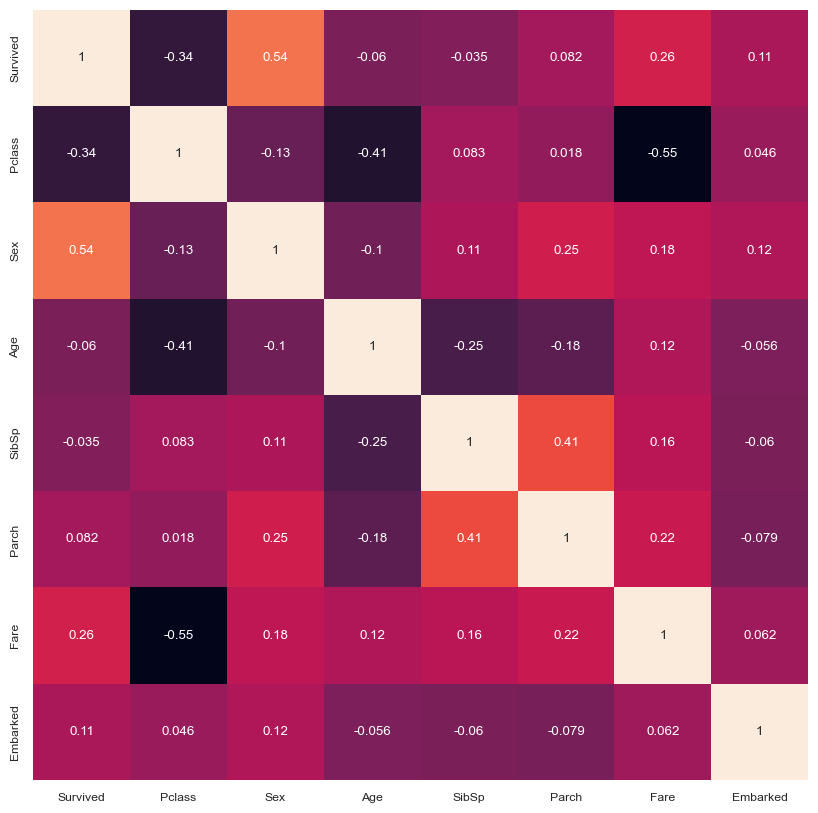

In [4]:
# 상관계수 히트맵 확인
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_corr.corr()
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(corr_matrix, annot=True, cbar=False)
plt.show()

In [5]:
# classification
# type 1
# y : survived
# X : drop survived and all data
from sklearn.model_selection import train_test_split

df_cl = df_corr

y = df_cl['Survived']
X = df_cl.drop(columns=["Survived"])

print(y.head())
print(X.head())

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

PassengerId
1    0
2    1
3    1
4    1
5    0
Name: Survived, dtype: int64
             Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
PassengerId                                                    
1                 3    0  22.0      1      0   7.2500         0
2                 1    1  38.0      1      0  71.2833         1
3                 3    1  26.0      0      0   7.9250         0
4                 1    1  35.0      1      0  53.1000         0
5                 3    0  35.0      0      0   8.0500         0


In [6]:
# classification modeling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

m1,m2,m3 = LogisticRegression(random_state=0), DecisionTreeClassifier(random_state=0), RandomForestClassifier(random_state=0)
m1.fit(X_train, y_train)
m2.fit(X_train, y_train)
m3.fit(X_train, y_train)
m1_y, m2_y, m3_y = m1.predict(X_test), m2.predict(X_test), m3.predict(X_test)

# 정확도와 혼동행렬 확인
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

print('--- LogisticRegression ---')
print(accuracy_score(y_test,m1_y))
print(confusion_matrix(y_test,m1_y))

print('--- DecisionTreeClassifier ---')
print(accuracy_score(y_test,m2_y))
print(confusion_matrix(y_test,m2_y))

print('--- RandomForestClassifier ---')
print(accuracy_score(y_test,m3_y))
print(confusion_matrix(y_test,m3_y))

--- LogisticRegression ---
0.8156424581005587
[[96 14]
 [19 50]]
--- DecisionTreeClassifier ---
0.8156424581005587
[[98 12]
 [21 48]]
--- RandomForestClassifier ---
0.8547486033519553
[[102   8]
 [ 18  51]]


c:\Users\June\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
# classification
# type 2
# y : survived
# X : sex, fare, embarked,
from sklearn.model_selection import train_test_split

df_cl2 = df_corr

y = df_cl2['Survived']
X = df_cl2[['Sex', 'Fare', 'Embarked','Pclass']]

print(y.head())
print(X.head())

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

PassengerId
1    0
2    1
3    1
4    1
5    0
Name: Survived, dtype: int64
             Sex     Fare  Embarked  Pclass
PassengerId                                
1              0   7.2500         0       3
2              1  71.2833         1       1
3              1   7.9250         0       3
4              1  53.1000         0       1
5              0   8.0500         0       3


In [8]:
# classification modeling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

m1,m2,m3 = LogisticRegression(random_state=0), DecisionTreeClassifier(random_state=0), RandomForestClassifier(random_state=0)
m1.fit(X_train, y_train)
m2.fit(X_train, y_train)
m3.fit(X_train, y_train)
m1_y, m2_y, m3_y = m1.predict(X_test), m2.predict(X_test), m3.predict(X_test)

# 정확도와 혼동행렬 확인
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

print('--- LogisticRegression ---')
print(accuracy_score(y_test,m1_y))
print(confusion_matrix(y_test,m1_y))

print('--- DecisionTreeClassifier ---')
print(accuracy_score(y_test,m2_y))
print(confusion_matrix(y_test,m2_y))

print('--- RandomForestClassifier ---')
print(accuracy_score(y_test,m3_y))
print(confusion_matrix(y_test,m3_y))

--- LogisticRegression ---
0.7877094972067039
[[92 18]
 [20 49]]
--- DecisionTreeClassifier ---
0.8212290502793296
[[96 14]
 [18 51]]
--- RandomForestClassifier ---
0.8268156424581006
[[96 14]
 [17 52]]


regression은 사실 적갑하지 않음

In [9]:
# regression
# type 1
# y : survived
# X : drop survived and all data
from sklearn.model_selection import train_test_split

df_re = df_corr

y = df_re['Survived']
X = df_re.drop(columns=["Survived"])

print(y.head())
print(X.head())

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=0)

PassengerId
1    0
2    1
3    1
4    1
5    0
Name: Survived, dtype: int64
             Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
PassengerId                                                    
1                 3    0  22.0      1      0   7.2500         0
2                 1    1  38.0      1      0  71.2833         1
3                 3    1  26.0      0      0   7.9250         0
4                 1    1  35.0      1      0  53.1000         0
5                 3    0  35.0      0      0   8.0500         0


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

m1 = LinearRegression()
m1.fit(X_train,y_train)
m1_y = m1.predict(X_test)

m2 = DecisionTreeRegressor()
m2.fit(X_train,y_train)
m2_y = m2.predict(X_test)

m3 = RandomForestRegressor()
m3.fit(X_train,y_train)
m3_y = m3.predict(X_test)

from sklearn.metrics import mean_squared_error # 평균제곱오차

print('---- LinearRegression ----')
print(mean_squared_error(y_test,m1_y))
print('---- DecisionTreeRegressor ----')
print(mean_squared_error(y_test,m2_y))
print('---- RandomForestRegressor ----')
print(mean_squared_error(y_test,m3_y))


---- LinearRegression ----
0.13706665282293315
---- DecisionTreeRegressor ----
0.17758052279467548
---- RandomForestRegressor ----
0.12294193062361293
